# 3) k-means clustering

- Type of model: UNSUPERVISED
- Model type of approach: feature-space clustering


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import confusion_matrix

PROC_DIR = Path("./../artifacts")
FIG_DIR = Path("./../figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())
y = (df["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth
N_FOLDS = sel["n_folds"]

print(f"{len(df)} windows, {df['recording_id'].nunique()} recordings, {df['participant'].nunique()} participants")
print(f"{len(sel['kept'])} features kept by the filters, {len(sel['all'])} candidates")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "orange", "smooth": "blue"}
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 3.1 Preprocessing

K-means uses Euclidean distance. Thus is sensitive to two things:

- **scale**: a feature with a large range dominates the distance, hence standardisation
- **skew**: A few extreme windows can pull a centroid towards one direction. With log transform these features roughly symmetric first. (Only for band-power/kurtosis features, which arent in the top 5 features)


In [1]:
LOG_FEATS = [f for f in sel["all"] if "_bp" in f or f.endswith("_kurt")]

def transform(frame, feats):
    Z = frame[feats].copy()
    for f in set(feats) & set(LOG_FEATS):
        Z[f] = np.log(Z[f] + 1e-12)
    return Z.to_numpy(float)

# feature sets, from small and interpretable to everything the filters kept
FEATURE_SETS = {
    "2D: vertbp_madiff + horiz_madiff": ["vertbp_madiff", "horiz_madiff"],
    "top-5 Fisher": sel["ranked_by_fisher"][:5],
    f"all kept ({len(sel['kept'])})": sel["kept"],
}

for name, feats in FEATURE_SETS.items():
    print(f"{name:35s} {feats if len(feats) <= 5 else '...'}")

NameError: name 'sel' is not defined

## 3.2 Determination of $k$

- **Inertia** (within-cluster sum of squares) decreases with $k$: we look for the elbow where adding a cluster stops helping much.
- **Silhouette** $s = (b-a)/\max(a,b)$ per window, with $a$ the mean distance to its own cluster and $b$ to the nearest other cluster. Closer to 1 means compact, well-separated clusters.

We know there are two road types, but the data does not have to agree: it might for example: split per participant or per ride first. Maybe interesting to discuss that it might even differ per device, or bike. 

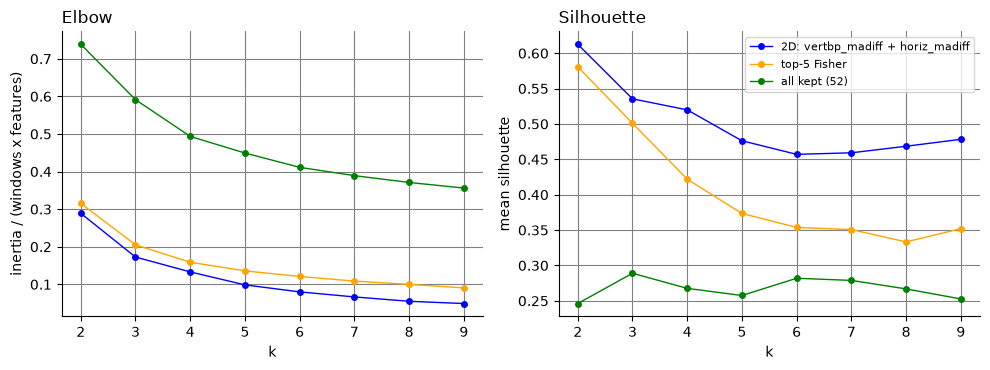

In [3]:
K_RANGE = range(2, 10)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

for (name, feats), color in zip(FEATURE_SETS.items(), PALETTE):
    Z = StandardScaler().fit_transform(transform(df, feats))
    norm_factor = len(Z) * Z.shape[1] # Pre-calculate to keep loop clean
    
    inertia, sil = [], []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
        
        inertia.append(km.inertia_ / norm_factor)
        
        # Added sample_size fixes performance freezing
        sil.append(silhouette_score(Z, km.labels_, sample_size=10000, random_state=0)) 
        
    plot_kws = dict(marker="o", markersize=4, color=color, label=name)
    ax1.plot(K_RANGE, inertia, **plot_kws)
    ax2.plot(K_RANGE, sil, **plot_kws)

# formatting 
ax1.set(xlabel="k", ylabel="inertia / (windows x features)", title="Elbow")
ax2.set(xlabel="k", ylabel="mean silhouette", title="Silhouette")
ax2.legend(fontsize=8)

for ax in (ax1, ax2): 
    ax.title.set(ha="left", x=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "kmeans_choose_k.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.3 $k = 2$ with two dimensions

With two features the algorithm creates: the centroids, and the boundary between them. 

We mark colour is the **true** label, background colour is the **cluster**.

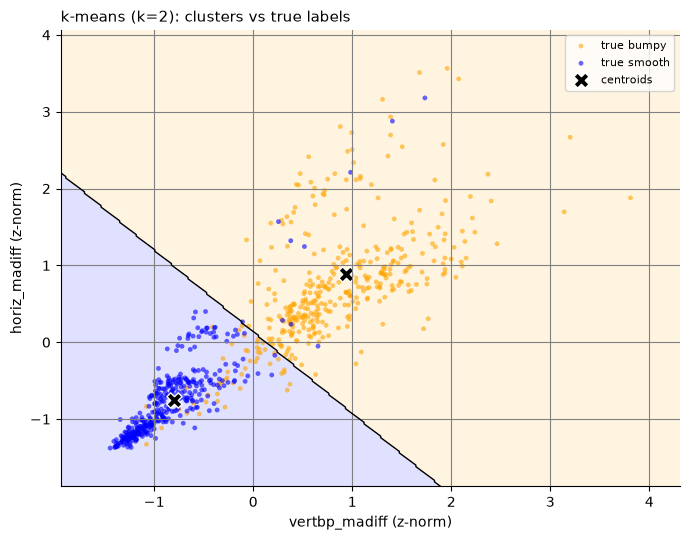

true label                bumpy  smooth
cluster (majority label)               
bumpy                       344      10
smooth                       51     363


In [4]:
feats2 = FEATURE_SETS["2D: vertbp_madiff + horiz_madiff"]
scaler2 = StandardScaler().fit(transform(df, feats2))
Z2 = scaler2.transform(transform(df, feats2))
km2 = KMeans(n_clusters=2, n_init=10, random_state=0).fit(Z2)

# naming each cluster after majority label inside it (only for colouring)
cl_name = {c: CLASSES[0] if y[km2.labels_ == c].mean() > 0.5 else CLASSES[1] for c in range(2)}

g0, g1 = np.meshgrid(np.linspace(Z2[:, 0].min() - 0.5, Z2[:, 0].max() + 0.5, 300),
                     np.linspace(Z2[:, 1].min() - 0.5, Z2[:, 1].max() + 0.5, 300))
grid_cl = km2.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(g0, g1, grid_cl, levels=[-0.5, 0.5, 1.5], alpha=0.12,
            colors=[CLASS_COLOR[cl_name[0]], CLASS_COLOR[cl_name[1]]])
ax.contour(g0, g1, grid_cl, levels=[0.5], colors="black", linewidths=1)

for lab in CLASSES:
    m = df["label"] == lab
    ax.scatter(Z2[m, 0], Z2[m, 1], s=12, alpha=0.6, color=CLASS_COLOR[lab], edgecolors="none", label=f"true {lab}")
    
ax.scatter(*km2.cluster_centers_.T, marker="X", s=120, color="black", edgecolors="white", label="centroids")
ax.set(xlabel=f"{feats2[0]} (z-norm)", ylabel=f"{feats2[1]} (z-norm)")
ax.set_title("k-means (k=2): clusters vs true labels", loc="left", fontsize=11)
ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "kmeans_2d.png", dpi=120, bbox_inches="tight"); plt.show()

print(pd.crosstab(
    pd.Series(km2.labels_, name="cluster").map(cl_name).rename("cluster (majority label)"),
    df["label"].rename("true label")))

## 3.4 Do the clusters match the labels?

Fitted on all windows (no labels involved in the fit so still unsupervised).

Metric to evaluate with labels:

- **Purity**: map every cluster to its majority label and count how many windows then match. For $k=2$ on balanced classes, 0.5 is chance by random.
- **Adjusted Rand index (ARI)**: agreement between two partitions, corrected for chance. 0 = random, 1 = identical. Unlike purity it does not reward using many clusters.

We also check $k=3$ and $k=4$: if the extra clusters split a class into sub-groups (for instance per participant) rather than mixing classes, purity stays high while ARI drops.

In [5]:
def purity(clusters, y):
    return sum(max((y[clusters == c] == 1).sum(), (y[clusters == c] == 0).sum()) for c in np.unique(clusters)) / len(y)

rows = []
for name, feats in FEATURE_SETS.items():
    Z = StandardScaler().fit_transform(transform(df, feats))
    for k in [2, 3, 4]:
        cl = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Z)
        rows.append({"feature set": name, "k": k, "purity": purity(cl, y),
                     "ARI vs label": adjusted_rand_score(y, cl),
                     "ARI vs participant": adjusted_rand_score(df["participant"], cl)})

agreement = pd.DataFrame(rows).set_index(["feature set", "k"])
agreement.round(3)

purity  ARI vs label  ARI vs participant
feature set                      k                                          
2D: vertbp_madiff + horiz_madiff 2   0.921         0.707              -0.002
                                 3   0.914         0.502               0.036
                                 4   0.909         0.451               0.021
top-5 Fisher                     2   0.915         0.690              -0.001
                                 3   0.919         0.524               0.009
                                 4   0.893         0.413               0.008
all kept (52)                    2   0.862         0.523               0.018
                                 3   0.773         0.238               0.195
                                 4   0.871         0.306               0.232

## 3.5 Micro-level evaluation: K-means conversion to classifier 

For comparison with supervised models, k-means is turned into a classifier:

1. fit the scaler and k-means ($k=2$) on the **training** windows only
2. name each cluster after the majority label of the training windows in it (the only place labels are used so now it is supervised)
3. assign each test window to its nearest centroid

Two splits: the grouped folds from feature-selection step (unseen recordings) and leave-one-participant-out (unseen rider). 

The baseline is the single-feature threshold on `vertbp_madiff` (midpoint between the class medians of the training data). Just a simple heuristic which evaluates whether model's complexity is even worth it (sanity check) 

In [6]:
def kmeans_classifier(tr, te, feats, k=2):
    scaler = StandardScaler().fit(transform(df[tr], feats))
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(scaler.transform(transform(df[tr], feats)))
    to_label = np.array([int(y[tr][km.labels_ == c].mean() > 0.5) for c in range(k)])
    
    return to_label[km.predict(scaler.transform(transform(df[te], feats)))]

def threshold_baseline(tr, te, f="vertbp_madiff"):
    x = df[f].to_numpy()
    thr = (np.median(x[tr][y[tr] == 1]) + np.median(x[tr][y[tr] == 0])) / 2
    
    return (x[te] > thr).astype(int)

SPLITS = {
    "grouped folds": [(df["fold"] != k, df["fold"] == k) for k in range(N_FOLDS)],
    "leave-one-participant-out": [(df["participant"] != p, df["participant"] == p) for p in sorted(df["participant"].unique())],
}

MODELS = {f"k-means, {name}": (lambda tr, te, feats=feats: kmeans_classifier(tr, te, feats)) for name, feats in FEATURE_SETS.items()}
MODELS["baseline: threshold on vertbp_madiff"] = threshold_baseline

rows = []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        acc = [(predict(tr.to_numpy(), te.to_numpy()) == y[te.to_numpy()]).mean() for tr, te in splits]
        rows.append({"split": split_name, "model": model_name, "mean acc": np.mean(acc), "worst split": np.min(acc)})

results = pd.DataFrame(rows).pivot(index="model", columns="split", values=["mean acc", "worst split"])
results.round(3)

mean acc  \
split                                     grouped folds   
model                                                     
baseline: threshold on vertbp_madiff              0.940   
k-means, 2D: vertbp_madiff + horiz_madiff         0.910   
k-means, all kept (52)                            0.834   
k-means, top-5 Fisher                             0.915   

                                                                     \
split                                     leave-one-participant-out   
model                                                                 
baseline: threshold on vertbp_madiff                          0.933   
k-means, 2D: vertbp_madiff + horiz_madiff                     0.906   
k-means, all kept (52)                                        0.797   
k-means, top-5 Fisher                                         0.890   

                                            worst split  \
split                                     grouped folds   
model                                                     
baseline: threshold on vertbp_madiff              0.884   
k-means, 2D: vertbp_madiff + horiz_madiff         0.805   
k-means, all kept (52)                            0.742   
k-means, top-5 Fisher                             0.842   

                                                                     
split                                     leave-one-participant-out  
model                                                                
baseline: threshold on vertbp_madiff                          0.921  
k-means, 2D: vertbp_madiff + horiz_madiff                     0.848  
k-means, all kept (52)                                        0.763  
k-means, top-5 Fisher                                         0.818

Conclusion: It seems that more features and this model are less effective than just single heuristic of vertical filtered mean difference feature

## 3.6 Macro Evaluation:  Per recording

Window accuracy hides whether errors are spread out or concentrated in a few rides. 

Below, for every recording, the fraction of its windows that ended up in the *bumpy* cluster (top-5 feature set, leave-one-participant-out, so every recording is predicted by a model that never saw that rider). 

Bumpy rides should be near 1, smooth rides near 0.

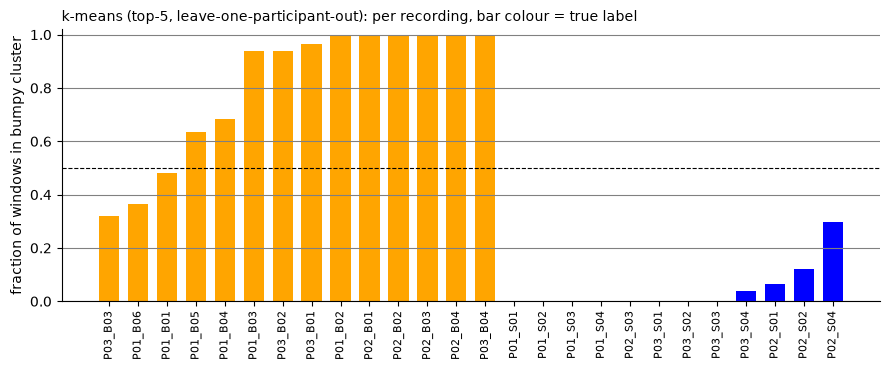

majority vote per recording: 88% of 26 recordings correct


In [7]:
feats = FEATURE_SETS["top-5 Fisher"]
pred = np.zeros(len(df), dtype=int)

for tr, te in SPLITS["leave-one-participant-out"]:
    pred[te.to_numpy()] = kmeans_classifier(tr.to_numpy(), te.to_numpy(), feats)

per_rec = (df.assign(pred_bumpy=pred).groupby("recording_id")
             .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean"), n_windows=("pred_bumpy", "size"))
             .sort_values(["label", "frac_bumpy"]))

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.bar(range(len(per_rec)), per_rec["frac_bumpy"], color=per_rec["label"].map(CLASS_COLOR), width=0.7)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(per_rec)), per_rec.index, rotation=90, fontsize=8)
ax.set(ylabel="fraction of windows in bumpy cluster", ylim=(0, 1.02))
ax.set_title("k-means (top-5, leave-one-participant-out): per recording, bar colour = true label", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "kmeans_per_recording.png", dpi=120, bbox_inches="tight"); plt.show()
rec_acc = ((per_rec["frac_bumpy"] > 0.5) == (per_rec["label"] == "bumpy")).mean()

print(f"majority vote per recording: {rec_acc:.0%} of {len(per_rec)} recordings correct")

## 3.7 Export results

Classifier model evaluation export for benchmarking/comparison later: 

- `kmeans_metrics_per_fold.csv`: one row per split, model and held-out fold / participant, with confusion counts
- `kmeans_metrics_summary.csv`: mean and worst fold per split and model
- `kmeans_predictions.csv`: out-of-fold prediction for every window, for comparing models later

- **precision**: of the windows predicted bumpy, the fraction that really are bumpy
- **recall**: of the bumpy windows, the fraction found
- **specificity**: of the smooth windows, the fraction correctly called smooth
- **balanced accuracy**: mean of recall and specificity, not affected by class imbalance within a fold

In [8]:
def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    safe = lambda a, b: a / b if b else np.nan
    precision, recall, specificity = safe(tp, tp + fp), safe(tp, tp + fn), safe(tn, tn + fp)
    
    return {"n": len(y_true), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy": (tp + tn) / len(y_true), "balanced_accuracy": (recall + specificity) / 2,
            "precision": precision, "recall": recall, "specificity": specificity,
            "f1": safe(2 * precision * recall, precision + recall)}

FOLD_NAMES = {"grouped folds": [f"fold {k}" for k in range(N_FOLDS)],
              "leave-one-participant-out": sorted(df["participant"].unique())}

metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
            tr, te = tr.to_numpy(), te.to_numpy()
            yhat = predict(tr, te)
            metric_rows.append({"split": split_name, "model": model_name, "held_out": fold_name,
                                **classification_metrics(y[te], yhat)})
            pred_frames.append(df.loc[te, ["recording_id", "participant", "label"]]
                               .assign(split=split_name, model=model_name, held_out=fold_name,
                                       pred=np.where(yhat == 1, "bumpy", "smooth")))

per_fold = pd.DataFrame(metric_rows)
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "kmeans_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "kmeans_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "kmeans_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)

saved to D:\2-Courses\5ARE0-Project\Machine_Learning_for_rides\artifacts\results


accuracy_mean  \
split                     model                                                      
grouped folds             baseline: threshold on vertbp_madiff               0.940   
                          k-means, 2D: vertbp_madiff + horiz_madiff          0.910   
                          k-means, all kept (52)                             0.834   
                          k-means, top-5 Fisher                              0.915   
leave-one-participant-out baseline: threshold on vertbp_madiff               0.933   
                          k-means, 2D: vertbp_madiff + horiz_madiff          0.906   
                          k-means, all kept (52)                             0.797   
                          k-means, top-5 Fisher                              0.890   

                                                                     balanced_accuracy_mean  \
split                     model                                                               
grouped folds             baseline: threshold on vertbp_madiff                        0.936   
                          k-means, 2D: vertbp_madiff + horiz_madiff                   0.901   
                          k-means, all kept (52)                                      0.815   
                          k-means, top-5 Fisher                                       0.908   
leave-one-participant-out baseline: threshold on vertbp_madiff                        0.938   
                          k-means, 2D: vertbp_madiff + horiz_madiff                   0.915   
                          k-means, all kept (52)                                      0.794   
                          k-means, top-5 Fisher                                       0.901   

                                                                     precision_mean  \
split                     model                                                       
grouped folds             baseline: threshold on vertbp_madiff                0.950   
                          k-means, 2D: vertbp_madiff + horiz_madiff           0.960   
                          k-means, all kept (52)                              0.866   
                          k-means, top-5 Fisher                               0.954   
leave-one-participant-out baseline: threshold on vertbp_madiff                0.946   
                          k-means, 2D: vertbp_madiff + horiz_madiff           0.971   
                          k-means, all kept (52)                              0.868   
                          k-means, top-5 Fisher                               0.955   

                                                                     recall_mean  \
split                     model                                                    
grouped folds             baseline: threshold on vertbp_madiff             0.915   
                          k-means, 2D: vertbp_madiff + horiz_madiff        0.830   
                          k-means, all kept (52)                           0.783   
                          k-means, top-5 Fisher                            0.853   
leave-one-participant-out baseline: threshold on vertbp_madiff             0.929   
                          k-means, 2D: vertbp_madiff + horiz_madiff        0.855   
                          k-means, all kept (52)                           0.751   
                          k-means, top-5 Fisher                            0.844   

                                                                     specificity_mean  \
split                     model                                                         
grouped folds             baseline: threshold on vertbp_madiff                  0.957   
                          k-means, 2D: vertbp_madiff + horiz_madiff             0.971   
                          k-means, all kept (52)                                0.847   
                          k-means, top-5 Fisher                                 0.963   
leave-one-p

**Conclusion:** without ever seeing a label, k-means rediscovers the bumpy/smooth split from vibration amplitude. This supports that the features do capture the road surface rather than the participant only. As a classifier it is not competitive compared to a simple heuristic function 
